# Esercitazione 02 Capacità


In [7]:
import pandas as pd

df = pd.read_csv('function_1000_25.csv')
print(df.head())
print(df.shape)

# Il dataset è composto da due colonne x,y e l'obiettivo è effettuare
# una regressione per predire y a partire da x

          X         y
0  1.872701  2.783879
1  4.753572 -2.698304
2  3.659970 -1.690942
3  2.993292 -0.404486
4  0.780093  0.497187
(1000, 2)


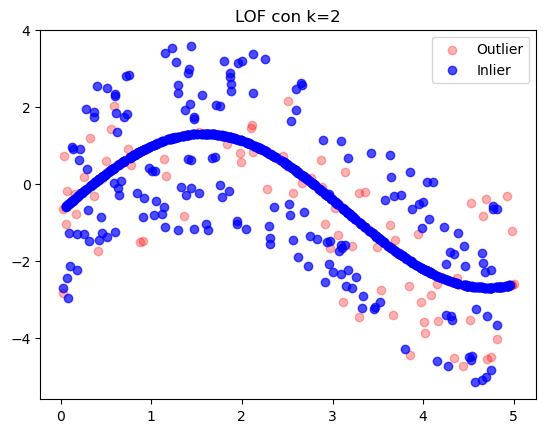

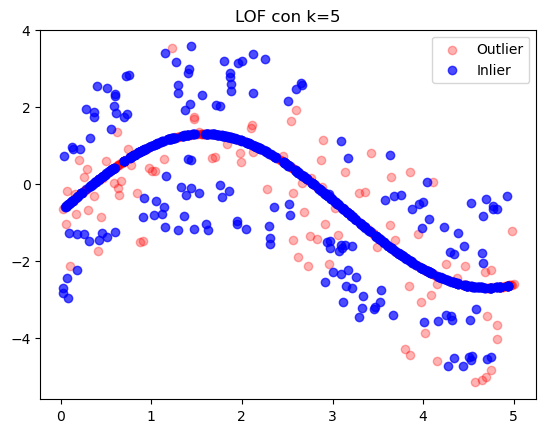

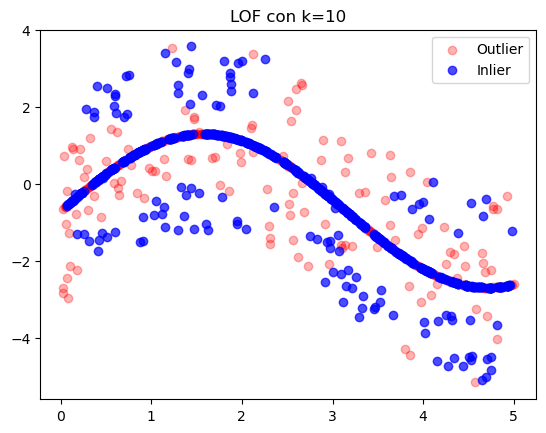

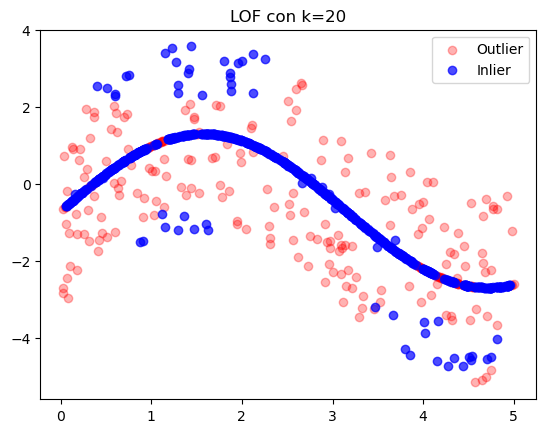

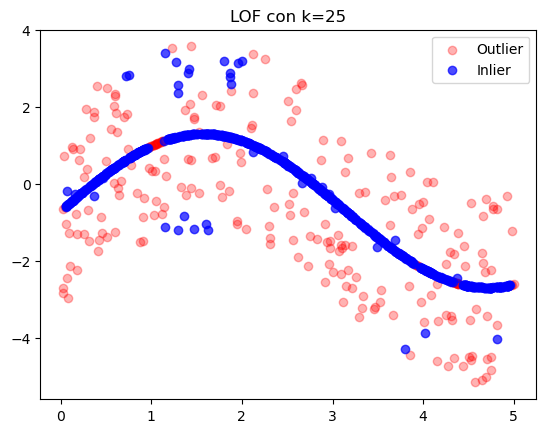

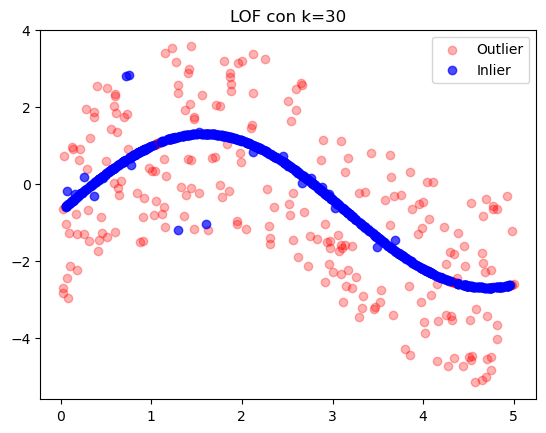

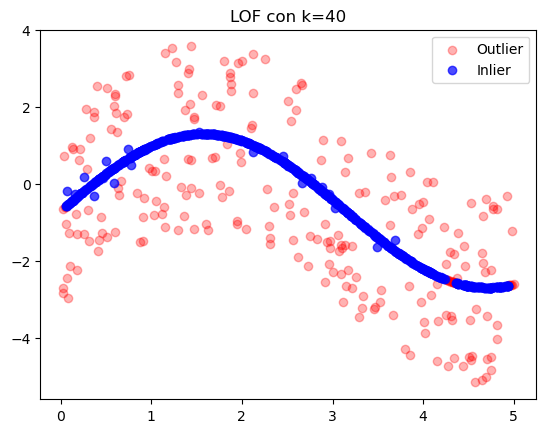

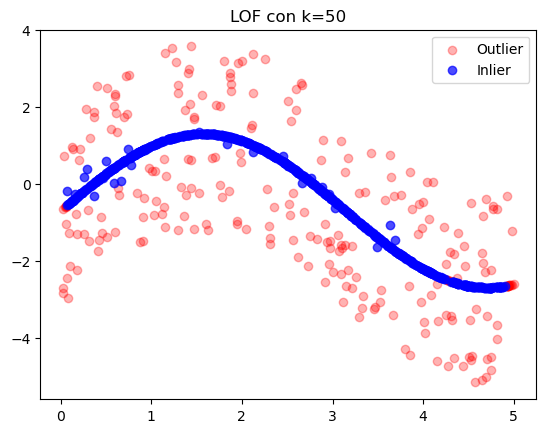

In [8]:
# pulizia delle anomalia tramite LOF
from sklearn.neighbors import LocalOutlierFactor
import matplotlib.pyplot as plt

# lista dei k vicini investigati
k_vicini = [2,5,10,20,25,30,40,50]

X = df[["X"]]
y = df["y"]

modelli_lof = []


for k in k_vicini:

    #Calcolo lof
    lof = LocalOutlierFactor(n_neighbors=k, contamination=0.25)

    #predizione degli outlier
    y_pred = lof.fit_predict(df[["X", "y"]]) # Restituisce 1 per inlier, -1 per outlier

    #Filtriamo i punti validi
    X_inliers = X[y_pred == 1]
    y_inliers = y[y_pred == 1]

    # Filtriamo gli outliers
    X_outliers = X[y_pred == -1]
    y_outliers = y[y_pred == -1]


    #Plot per il confronto visivo
    plt.scatter(X_outliers,y_outliers, color='red', label='Outlier', alpha=0.3)
    plt.scatter(X_inliers,y_inliers, color='blue', label='Inlier', alpha=0.7)
    plt.title(f"LOF con k={k}")
    plt.legend()
    modelli_lof.append(lof)    
    plt.show()


Scegliamo k=10 per una maggiore stabilità

# Regressione polinomiale: Calcolo MSE su 20 run

In [9]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

lof_def = LocalOutlierFactor(n_neighbors=10, contamination=0.25)

y_pred_def = lof_def.fit_predict(df[["X", "y"]])

X_inliers_def = X[y_pred_def == 1]
y_inliers_def = y[y_pred_def == 1]

# Lista di gradi per il nostro polinomio interpolante
grades_list = [1, 2, 3, 4, 5, 8, 10, 12, 15]

# Liste definitive per i valori medi
mean_mse_train = []
mean_mse_test = []

std_mse_train = []
std_mse_test = []

for grade in grades_list:
    mse_train_runs = []
    mse_test_runs = []

    
    poly = PolynomialFeatures(degree=grade)

    for run in range(20):

        # 1. Split (NON fissiamo il random_state per avere split sempre diversi)
        X_train, X_test, y_train, y_test = train_test_split(X_inliers_def, y_inliers_def, test_size=0.20)

        # 2. Trasformazione polinomiale (fit_transform su train, solo transform su test)
        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)

        # 3. Addestramento LinearRegression
        lr = LinearRegression()
        lr.fit(X_train_poly,y_train)
        
        # 4. Calcolo e salvataggio MSE della run corrente
        y_pred_train = lr.predict(X_train_poly)
        y_pred_test = lr.predict(X_test_poly)

        mse_train = mean_squared_error(y_train, y_pred_train)
        mse_test = mean_squared_error(y_test, y_pred_test)

        mse_train_runs.append(mse_train)
        mse_test_runs.append(mse_test)

    # Calcolo medie e deviazioni standard MSE
    mean_mse_train.append(np.mean(mse_train_runs))
    std_mse_train.append(np.std(mse_train_runs))
    
    mean_mse_test.append(np.mean(mse_test_runs))
    std_mse_test.append(np.std(mse_test_runs))

    # Stampa i risultati del grado corrente
    print(f"\nGrado del polinomio: {grade}")
    print(f"MSE train medio: {mean_mse_train[-1]:.4f}")
    print(f"Deviazione standard MSE train: {std_mse_train[-1]:.4f}")
    print(f"MSE test medio: {mean_mse_test[-1]:.4f}")
    print(f"Deviazione standard MSE test: {std_mse_test[-1]:.4f}")
            


Grado del polinomio: 1
MSE train medio: 1.1279
Deviazione standard MSE train: 0.0280
MSE test medio: 1.1261
Deviazione standard MSE test: 0.1119

Grado del polinomio: 2
MSE train medio: 0.7003
Deviazione standard MSE train: 0.0274
MSE test medio: 0.6829
Deviazione standard MSE test: 0.1095

Grado del polinomio: 3
MSE train medio: 0.5035
Deviazione standard MSE train: 0.0234
MSE test medio: 0.4865
Deviazione standard MSE test: 0.0945

Grado del polinomio: 4
MSE train medio: 0.4825
Deviazione standard MSE train: 0.0218
MSE test medio: 0.5113
Deviazione standard MSE test: 0.0872

Grado del polinomio: 5
MSE train medio: 0.4878
Deviazione standard MSE train: 0.0166
MSE test medio: 0.4797
Deviazione standard MSE test: 0.0667

Grado del polinomio: 8
MSE train medio: 0.4703
Deviazione standard MSE train: 0.0231
MSE test medio: 0.4948
Deviazione standard MSE test: 0.0931

Grado del polinomio: 10
MSE train medio: 0.4695
Deviazione standard MSE train: 0.0169
MSE test medio: 0.4926
Deviazione sta

# Plot finale

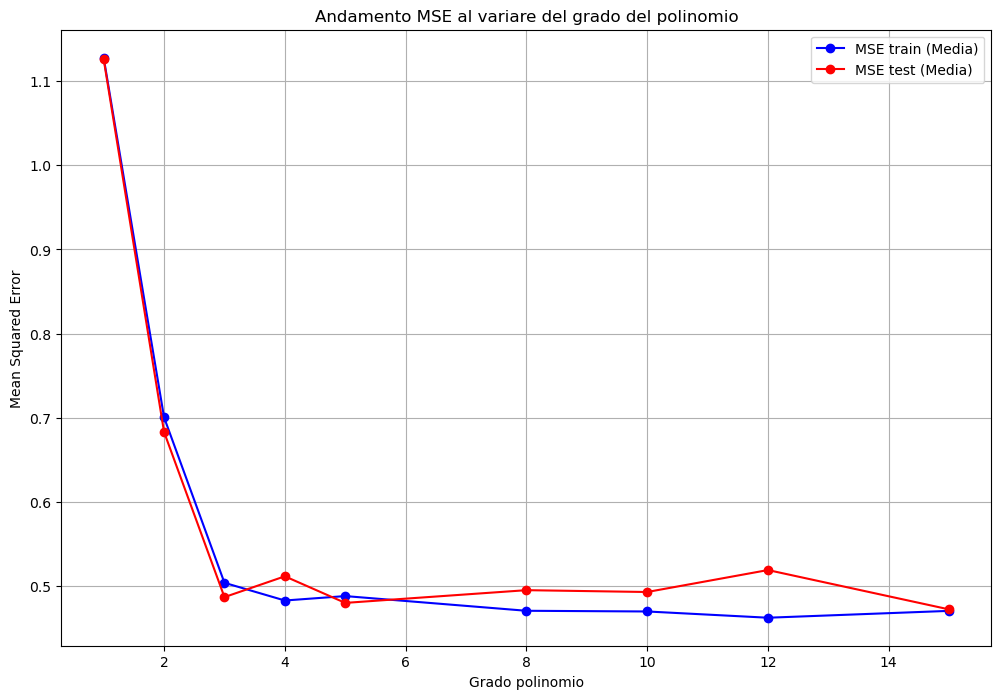

In [10]:
plt.figure(figsize=(12,8))

# Plot degli errori medi
plt.plot(grades_list, mean_mse_train, label = 'MSE train (Media)', color='blue', marker='o')
plt.plot(grades_list, mean_mse_test, label = 'MSE test (Media)', color='red', marker='o')

plt.title("Andamento MSE al variare del grado del polinomio")
plt.xlabel("Grado polinomio")
plt.ylabel("Mean Squared Error")

plt.legend()
plt.grid(True)
plt.show()
